# E5, E9 — Honestidad metodológica

- **E5:** ¿son confiables las *confianzas* que reporta el modelo? ¿ayuda que se **abstenga** en los casos dudosos?
- **E9:** ¿es el modelo **equitativo** entre ejes temáticos y clases? (análogo local a SageMaker Clarify)

Estos dos experimentos no buscan subir el F1, sino elevar el **rigor** y la **honestidad** del sistema, que es lo que un revisor valora.

In [1]:
# ============================================================================
# CONFIGURACION COMUN
# ----------------------------------------------------------------------------
# Este bloque prepara el entorno. Se repite en todos los notebooks para que
# cada uno sea autonomo (se pueda abrir y correr por separado).
# ============================================================================
import sys                     # para anadir la carpeta 'src' al path de importacion
import json                    # los resultados de cada experimento se guardan como JSON
from pathlib import Path       # manejo de rutas independiente del sistema operativo

# Anadimos experimentos/src al path para poder importar el codigo compartido
# (metricas ordinales, carga de datos, semillas). Usamos rutas relativas para
# que el notebook funcione sin importar donde este clonado el repositorio.
sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np             # calculo numerico (vectores de predicciones)
import pandas as pd            # tablas de resultados legibles
import common as C             # nuestro modulo: metricas ordinales, carga del gold, semilla

# Carpeta donde viven los resultados ya calculados (un JSON por experimento).
R = C.RESULTS

def load(nombre_archivo):
    """Carga un JSON de resultados desde experimentos/resultados/."""
    return json.load(open(R / nombre_archivo))

# --- PATRON DE DOS NIVELES (buena practica de reproducibilidad) ---
# Por defecto RECOMPUTE=False: el notebook CARGA los resultados ya calculados,
# corre en segundos y NO necesita GPU ni Amazon Bedrock. Asi un revisor puede
# abrirlo y ver todo sin infraestructura.
# Si pones RECOMPUTE=True, las celdas marcadas volveran a ENTRENAR/LLAMAR a la nube
# (requiere el venv de ML y/o credenciales de Bedrock; toma minutos a horas).
RECOMPUTE = False

# Fijamos la semilla global para que cualquier calculo aleatorio (p.ej. bootstrap)
# sea reproducible: dos ejecuciones dan el mismo numero.
C.set_all_seeds(C.SEED)
print(f"Entorno listo. Semilla global = {C.SEED}. RECOMPUTE = {RECOMPUTE}.")

Entorno listo. Semilla global = 61298. RECOMPUTE = False.


## E5 — Calibración (temperature scaling) + abstención

Una red neuronal suele estar **mal calibrada**: dice "90% seguro" y acierta el 70%. El *temperature scaling* ajusta un único escalar T que corrige esa sobreconfianza. Luego medimos qué pasa si el modelo **se abstiene** de los casos donde menos confía (curva risk-coverage).

ECE (error de calibracion): 0.094 -> 0.089  (temperatura T=1.49)
(T>1 indica que el modelo estaba sobreconfiado; T lo suaviza.)



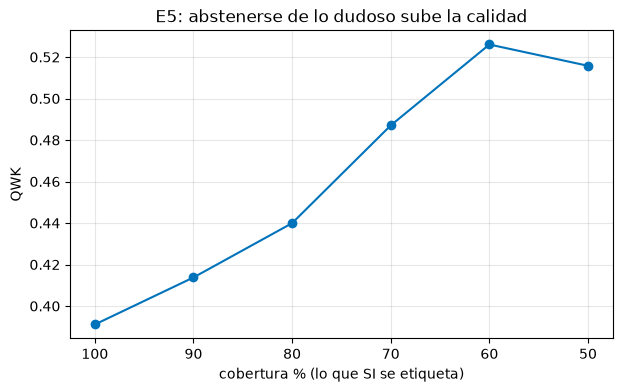

In [2]:
# E5: calibracion y abstencion.
e5 = load("e5_calibracion.json")

# ECE = Expected Calibration Error: mide cuanto miente la confianza (menor = mejor).
print(f"ECE (error de calibracion): {e5['ece_before']:.3f} -> {e5['ece_after']:.3f}  (temperatura T={e5['T']:.2f})")
print(f"(T>1 indica que el modelo estaba sobreconfiado; T lo suaviza.)")
print()

# Curva risk-coverage: QWK sobre el subconjunto mas confiable, al abstenerse del resto.
import matplotlib.pyplot as plt
cobertura = [r["coverage"] * 100 for r in e5["risk_coverage"]]   # % del corpus que SI se etiqueta
qwk       = [r["qwk"] for r in e5["risk_coverage"]]              # calidad sobre lo etiquetado
plt.figure(figsize=(7, 4))
plt.plot(cobertura, qwk, "-o", color="#0073bb")
plt.gca().invert_xaxis()   # de mayor a menor cobertura, para leer "cuanto sube al abstenerse"
plt.xlabel("cobertura % (lo que SI se etiqueta)"); plt.ylabel("QWK")
plt.title("E5: abstenerse de lo dudoso sube la calidad"); plt.grid(alpha=0.3); plt.show()

Al etiquetar solo el 60% donde más confía, el QWK sube de 0.391 a 0.526. **Para medir opinión pública es más honesto reportar "X% negativo, Y% incierto"** que forzar una etiqueta dudosa. Convierte una debilidad (el 40% de baja confianza) en una contribución.

## E9 — Análisis de sesgo (análogo local a SageMaker Clarify)

En vez de gastar crédito montando SageMaker (que solo daría reproducibilidad, no mejora de F1), implementamos localmente la parte valiosa: medir si el modelo es equitativo.

In [3]:
# E9: analisis de equidad y sesgo sobre las predicciones out-of-fold.
e9 = load("e9_bias.json")

# (a) Equidad de grupo: QWK por eje tematico. Una brecha grande = trato desigual.
print("QWK por eje:", {k: round(v["qwk"], 3) for k, v in e9["axis_performance"].items()})
print(f"Brecha entre ejes: {e9['axis_qwk_gap']:.3f}  (infraestructura es el eje mas dificil)")
print()

# (b) Sesgo de distribucion: el modelo, ¿sobre/sub-predice alguna clase?
print("Sesgo por clase (puntos porcentuales, predicho - real):",
      {k: round(v, 1) for k, v in e9["class_bias_pp"].items()})
print("=> sub-predice la clase neutral (3) en -7.7 pp: tiende a 'tomar postura'.")
print()

# (c) Matriz de confusion: donde caen los errores (idealmente en clases vecinas).
print("Matriz de confusion (fila = real, columna = predicho):")
print(np.array(e9["confusion_matrix"]))

QWK por eje: {'seguridad': 0.423, 'infraestructura': 0.372, 'turismo': 0.405}
Brecha entre ejes: 0.051  (infraestructura es el eje mas dificil)

Sesgo por clase (puntos porcentuales, predicho - real): {'1': 1.4, '2': 2.4, '3': -7.7, '4': 2.4, '5': 1.5}
=> sub-predice la clase neutral (3) en -7.7 pp: tiende a 'tomar postura'.

Matriz de confusion (fila = real, columna = predicho):
[[103  40  25   3   2]
 [ 40  68  36  10   5]
 [ 31  54  87  21  11]
 [  5   8   9   7   1]
 [  2   3   2   3   5]]


## Veredicto de E5-E9
El modelo es **peor en infraestructura** (eje más ambiguo) y tiene un **sesgo anti-neutral**. Los errores caen en clases vecinas (buena propiedad ordinal). Esto es material honesto para la sección de ética/limitaciones de la tesis, obtenido a $0 sin SageMaker.